In [3]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
sns.get_dataset_names()



['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [5]:
df = sns.load_dataset('taxis')
df.head()



,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [6]:
df.shape

(6433, 14)

In [7]:
df = df[["distance", "fare"]]
df



,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0
...,...,...
6428,0.75,4.5
6429,18.74,58.0
6430,4.14,16.0
6431,1.12,6.0


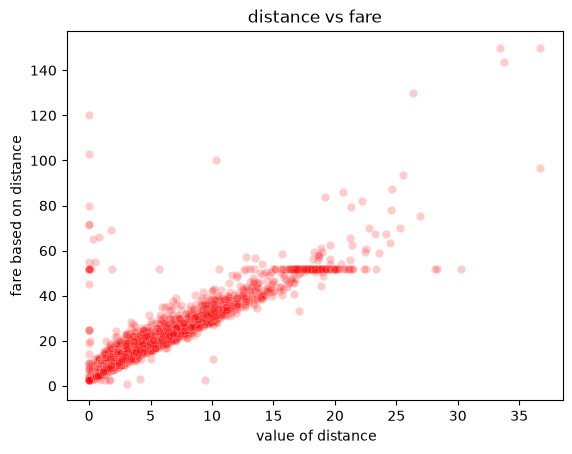

<Figure size 1000x600 with 0 Axes>

In [8]:
sns.scatterplot(x= df["distance"],y = df["fare"],color = "red",alpha = 0.2)
plt.title("distance vs fare")
plt.xlabel(" value of distance")
plt.ylabel("fare based on distance")
plt.figure(figsize=(10,6))
plt.show()


In [9]:
df.isna().sum()

distance    0
fare        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2978)

In [11]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [12]:
df.head()

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0


In [13]:
df.info()


<class 'pandas.DataFrame'>
Index: 3455 entries, 0 to 6432
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   distance  3455 non-null   float64
 1   fare      3455 non-null   float64
dtypes: float64(2)
memory usage: 81.0 KB


In [14]:
df.describe()

,distance,fare
count,3455.000000,3455.000000
mean,4.365847,17.424420
std,4.617425,13.648461
min,0.000000,1.000000
25%,1.440000,8.500000
50%,2.680000,13.000000
75%,5.320000,21.000000
max,36.700000,150.000000


<Axes: >

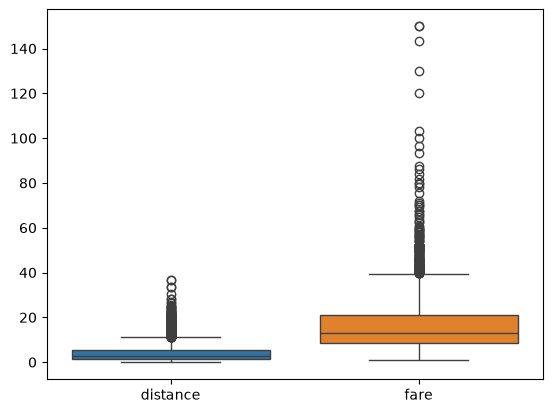

In [15]:
sns.boxplot(df)

In [16]:
x = df[["distance"]]
y = df[["fare"]]


<Axes: >

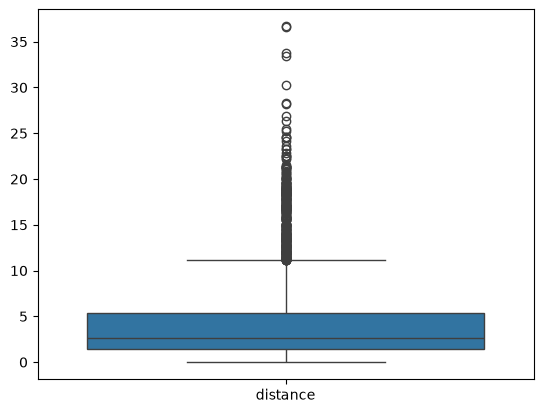

In [17]:
sns.boxplot(x)

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
linear_model = lr.fit(x_train,y_train)
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[2.67]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['distance']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[5.79]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [19]:
linear_model.score(x_train,y_train)

0.8356707954997834

In [20]:
linear_model.score(x_test,y_test)

0.7794338799671384

In [21]:
linear_model.predict([[2.16]])


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[11.54959116]])

In [22]:
y_pred = linear_model.predict(x_test)


In [23]:
y_test

,fare
594,31.0
51,12.0
1586,12.0
3718,26.5
648,9.0
...,...
3644,103.0
724,5.0
5605,3.5
6402,11.5


In [24]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse, r2, mae


(43.22049190547442, 0.7794338799671384, 2.7033611531080877)

In [25]:
from sklearn.preprocessing import StandardScaler

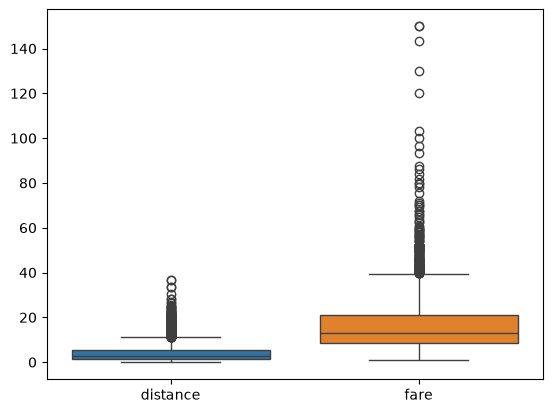

In [28]:
sns.boxplot(df)
plt.show()

In [29]:
def outlier_rem(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

In [30]:
new_df = outlier_rem(df, "distance")

In [31]:
new_df = outlier_rem(new_df, "fare")

In [32]:
new_df.shape

(3041, 2)

<Axes: >

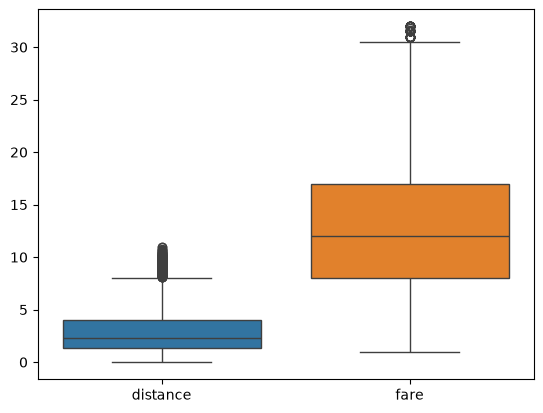

In [33]:
sns.boxplot(new_df)

In [34]:
df = new_df.copy()

In [35]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

for col in df.columns:
    df[col] = std.fit_transform(df[[col]])

df.head()

,distance,fare
0,-0.617966,-0.945094
1,-0.968667,-1.239533
2,-0.717548,-0.871484
3,2.023113,1.999294
4,-0.375507,-0.650655


In [36]:
x = df[["distance"]]
y = df["fare"]

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
linear_model = lr.fit(x_train,y_train)
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.93]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['distance']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.003715
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [39]:
y_pred = linear_model.predict(x_test)


In [40]:
y_test

367     0.747929
5722    1.557636
152    -0.724265
672    -1.313143
1331   -0.724265
          ...   
5555    0.159052
4607   -1.018704
620    -0.871484
3829    0.895149
245    -0.208997
Name: fare, Length: 609, dtype: float64

In [41]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse, r2, mae


(0.17268389581663265, 0.8371680164112407, 0.3040031229715494)

In [42]:
import pandas as pd

result = pd.DataFrame({
    "Metric": ["MSE", "R² Score", "MAE"],
    "Before Outlier": [43.22049190547442, 0.7794338799671384, 2.7033611531080877],
    "After Outlier": [0.17268389581663265, 0.8371680164112407, 0.3040031229715494]
})

result

,Metric,Before Outlier,After Outlier
0,MSE,43.220492,0.172684
1,R² Score,0.779434,0.837168
2,MAE,2.703361,0.304003


In [ ]:
import pickle

pickle.dump(linear_model, open("fare_model.pkl", "wb"))

pickle.dump(std, open("scaler.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully
